In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


data = pd.read_csv('data/dataset_malware.csv').drop(['Name'], axis=1)

le = LabelEncoder()
for column in data: data[column] = le.fit_transform(data[column])

features = data.drop(['Malware'], axis=1)
labels = data['Malware']

train_features,test_features,train_labels,test_labels = train_test_split(features,labels,test_size = 0.2)


#### Entraînement de modèles

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

model_classes = [KNeighborsClassifier, LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVC, GaussianNB]
model_classes = [LogisticRegression, DecisionTreeClassifier, RandomForestClassifier]

In [28]:
!pip install tqdm
from tqdm import tqdm
import time

models = []

for model in tqdm(model_classes):    
    classifier = model()

    start_time = time.time()
    classifier = classifier.fit(train_features, train_labels)
    train_time = time.time() - start_time

    start_time = time.time()
    predicted_labels = classifier.predict(test_features)
    predict_time = time.time() - start_time

    accuracy = accuracy_score(test_labels, predicted_labels)

    models.append({
        'model_name': model.__name__,
        'model': classifier,
        'predictions': predicted_labels,
        'accuracy': accuracy,
        'train_time': train_time,
        'predict_time_total': predict_time,
        'predict_time_single_in_milliseconds': predict_time / len(test_features) * 1000,
        'predict_throughtput_per_second': len(test_features) / predict_time,
    })

Defaulting to user installation because normal site-packages is not writeable


  0%|          | 0/3 [00:00<?, ?it/s]/home/hp/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 3/3 [00:12<00:00,  4.25s/it]


In [19]:
# analyse de la performance des modèles : partie 1
results = pd.DataFrame(models)
results[['model', 'accuracy', 'train_time', 'predict_time_total']].sort_values(by='accuracy', ascending=False)

,model,accuracy,train_time,predict_time_total
2,RandomForestClassifier,0.991843,6.069022,0.190601
1,DecisionTreeClassifier,0.985470,0.872745,0.012716
0,LogisticRegression,0.888351,2.631573,0.013520


In [20]:
# analyse de la performance des modèles : complète
results = pd.DataFrame(models)
results.drop(['predictions'], axis=1).sort_values(by='accuracy', ascending=False)

,model,accuracy,train_time,predict_time_total,predict_time_single_ms,predict_throughtput
2,RandomForestClassifier,0.991843,6.069022,0.190601,0.048585,20582.303036
1,DecisionTreeClassifier,0.985470,0.872745,0.012716,0.003241,308513.417182
0,LogisticRegression,0.888351,2.631573,0.013520,0.003446,290152.437744


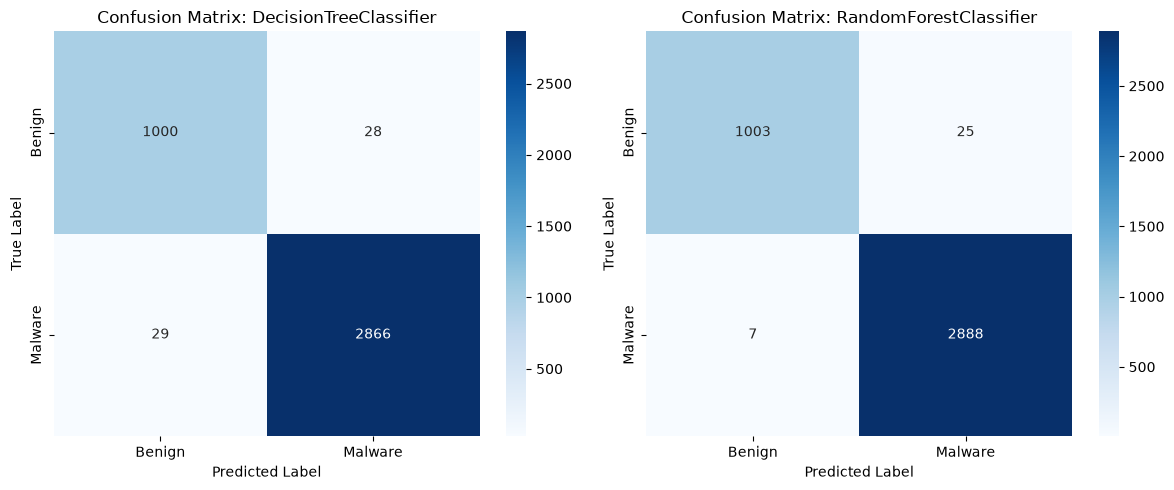

In [ ]:
# analyse du niveau de risque par modèle 

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

chosen_models = ['DecisionTreeClassifier', 'RandomForestClassifier']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class 0: Benign, Class 1: Malware
labels = ['Benign', 'Malware']

for idx, model in enumerate(chosen_models):
    y_pred = results[results['model'] == model]['predictions'].values[0]
    cm = confusion_matrix(test_labels, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=labels, yticklabels=labels)
    
    axes[idx].set_title(f'Confusion Matrix: {model}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Verdict : Meilleur modèle
Taille de jeu de données : 6.7 Mo en format csv.

Modèle : 

Accuracy : 
Risque : 
Besoin : 77 colonnes.

Temps d'exécution : secondes pour 19611 prédictions, soit par prédiction.

Pouvoir explicatif : 

In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

target = 'FFFFFFFFFF'  # Change this to the model you want to visualize
final_model = next(item['model'] for item in models if item['model_name'] == target)

# Select estimator if Random Forest; otherwise use final_model directly
tree = final_model.estimators_[0] if hasattr(final_model, 'estimators_') else final_model

plt.figure(figsize=(100, 50))
plot_tree(
    tree,
    feature_names=train_features.columns,
    class_names=['Benign', 'Malware'],
    filled=True,
    max_depth=3
)
plt.title("Tree Visualization")

# Save to current working directory
output_path = os.path.join(os.getcwd(), 'tree_visualization.png')
plt.savefig(output_path, dpi=100, bbox_inches='tight')
plt.close()

In [ ]:
from sklearn.tree import export_text

# Generate text rules
tree_rules = export_text(
    tree,
    feature_names=list(train_features.columns),
    show_weights=True
)

# Write to a file in the current working directory
file_path = os.path.join(os.getcwd(), 'tree_rules.txt')
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(tree_rules)

In [ ]:
from sklearn.tree import _tree

def tree_to_code(tree, feature_names, file_path):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]

    with open(file_path, "w", encoding="utf-8") as f:
        f.write("def predict(sample):\n")

        def recurse(node, depth):
            indent = "    " * depth
            if tree_.feature[node] != _tree.TREE_UNDEFINED:
                name = feature_name[node]
                threshold = tree_.threshold[node]
                f.write(f"{indent}if sample['{name}'] <= {threshold:.6f}:\n")
                recurse(tree_.children_left[node], depth + 1)
                f.write(f"{indent}else:\n")
                recurse(tree_.children_right[node], depth + 1)
            else:
                # Class 0: Benign, Class 1: Malware
                prediction = int(tree_.value[node].argmax())
                f.write(f"{indent}return {prediction}  # 0: Benign, 1: Malware\n")

        recurse(0, 1)

output_file = os.path.join(os.getcwd(), 'decision_rules.py')
tree_to_code(tree, list(train_features.columns), output_file)

# À faire : 
1. Exécutez le même code. Avez-vous eu le même résultats que moi?

2. êtes-vous capables de faire sortir le raisonnement des autres modèles? Si oui, comment l'expliqueriez-vous à votre supérieur?